In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from core.data import load_from_kaggle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
dataset_link = "saireddypothireddy/human-data-sequence-dataset" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\human-data-sequence-dataset' already exists with files. Skipping download (replace=False).


In [3]:
files

['Human Data Sequnence.txt']

In [4]:
my_path = "../data/raw/human-data-sequence-dataset/Human Data Sequnence.txt"
with open(my_path, "r") as f:
    file = f.read()
file[:500]

'sequence\tclass\nATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCATACTCCTTACACTATTCCTCATCACCCAACTAAAAATATTAAACACAAACTACCACCTACCTCCCTCACCAAAGCCCATAAAAATAAAAAATTATAACAAACCCTGAGAACCAAAATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG\t4\nATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAGGCCTACCCGCCGCAGTACTGATCATTCTATTTCCCCCTCTATTGATCCCCACCTCCAAATATCTCATCAACAACCGACTAATCACCACCCAACAATGACTAATCAAACTAACCTCAAAACAAATGATAACCATACACAACACTAAAGGACGAACCTGATCTCTTATACTAGTATCCTTAATCATTTTTATTGCCACAACTAACCTCCTCGGACTCCTGCCTCACTCATT'

In [5]:
df = pd.read_csv(my_path, sep='\t')
sequences = df["sequence"].values
df.head()

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3


In [6]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(4380, 2)

'Description'

,count,mean,std,min,25%,50%,75%,max
class,4380.0,3.5,2.13,0.0,2.0,4.0,6.0,6.0


'Duplicates'

np.int64(751)

,Data Types,Missing Values,Unique Values,Sample Values
sequence,object,0,3629,[ATGGCCCGAAGACCCCGGCACAGCATATATAGCAGTGACGAGGAT...
class,int64,0,7,"[1, 3, 6]"


In [16]:
#search the best k-mer value for clustering
for k in [3, 4, 5]:
    vectorizer = CountVectorizer(analyzer="char", ngram_range=(k, k))
    X = vectorizer.fit_transform(sequences)
    X_scaled = StandardScaler(with_mean=False).fit_transform(X)
    clusters = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    print(f"k-mer={k}, silhouette={score:.3f}")

k-mer=3, silhouette=0.373
k-mer=4, silhouette=0.315
k-mer=5, silhouette=0.267


In [14]:
#K-mer Feature Extraction
k = 3 
vectorizer = CountVectorizer(analyzer="char", ngram_range=(k, k))
X = vectorizer.fit_transform(sequences)

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

n_clusters = 3
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)
display(df)

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3
...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6


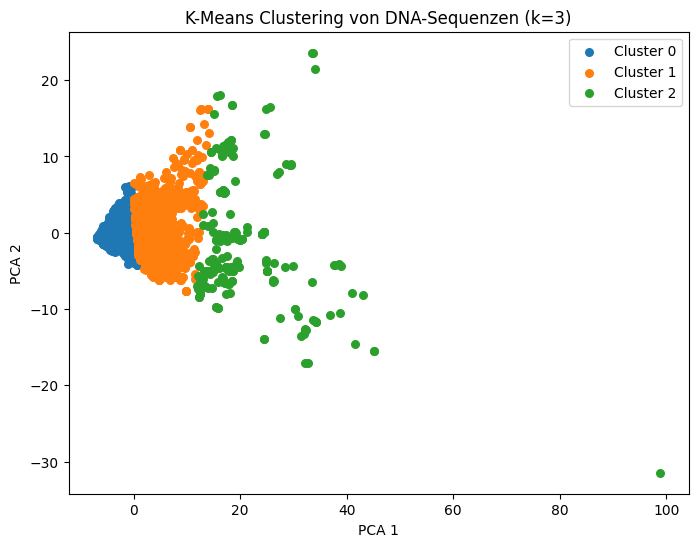

In [15]:
#PCA zur Visualisierung
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled.toarray())
unique_clusters = np.unique(clusters)
plt.figure(figsize=(8, 6))

for cluster_id in unique_clusters:
    idx=clusters==cluster_id
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=30,
        label=f"Cluster {cluster_id}"
    )
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering von DNA-Sequenzen (k=3)")
plt.legend()
plt.show()